# 02 - Analyse exploratoire des données (EDA)

**Objectif du notebook :** explorer la qualité et les caractéristiques du dataset Online Retail II 
pour identifier les anomalies, valeurs manquantes et tendances, avant de définir les règles de nettoyage.

**Cadrage, Acquisition & Nettoyage**

## 1. Chargement du dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_parquet("../data/raw/online_retail_full.parquet")
df.shape

(1067371, 8)

## 2. Vue d'ensemble

In [2]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,1.067371e+06,1067371,1.067371e+06,824364.000000
mean,9.938898e+00,2011-01-02 21:13:55.394029,4.649388e+00,15324.638504
min,-8.099500e+04,2009-12-01 07:45:00,-5.359436e+04,12346.000000
25%,1.000000e+00,2010-07-09 09:46:00,1.250000e+00,13975.000000
50%,3.000000e+00,2010-12-07 15:28:00,2.100000e+00,15255.000000
75%,1.000000e+01,2011-07-22 10:23:00,4.150000e+00,16797.000000
max,8.099500e+04,2011-12-09 12:50:00,3.897000e+04,18287.000000
std,1.727058e+02,NaN,1.235531e+02,1697.464450


In [3]:
df["Invoice"].nunique()

53628

In [4]:
df["StockCode"].nunique()

5305

In [5]:
df["Customer ID"].nunique()

5942

In [6]:
df["Country"].nunique()

43

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  string        
 1   StockCode    1067371 non-null  string        
 2   Description  1062989 non-null  string        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  string        
dtypes: datetime64[us](1), float64(2), int64(1), string(4)
memory usage: 117.3 MB


In [3]:
df.describe(include="all")

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
count,1067371,1067371,1062989,1.067371e+06,1067371,1.067371e+06,824364.000000,1067371
unique,53628,5305,5698,NaN,NaN,NaN,NaN,43
top,537434,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,1350,5829,5918,NaN,NaN,NaN,NaN,981330
mean,NaN,NaN,NaN,9.938898e+00,2011-01-02 21:13:55.394029,4.649388e+00,15324.638504,NaN
min,NaN,NaN,NaN,-8.099500e+04,2009-12-01 07:45:00,-5.359436e+04,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000e+00,2010-07-09 09:46:00,1.250000e+00,13975.000000,NaN
50%,NaN,NaN,NaN,3.000000e+00,2010-12-07 15:28:00,2.100000e+00,15255.000000,NaN
75%,NaN,NaN,NaN,1.000000e+01,2011-07-22 10:23:00,4.150000e+00,16797.000000,NaN
max,NaN,NaN,NaN,8.099500e+04,2011-12-09 12:50:00,3.897000e+04,18287.000000,NaN


## 3. Valeurs manquantes

In [4]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [5]:
(df.isnull().mean() * 100).round(2)

Invoice         0.00
StockCode       0.00
Description     0.41
Quantity        0.00
InvoiceDate     0.00
Price           0.00
Customer ID    22.77
Country         0.00
dtype: float64

## 4. Doublons

In [8]:
print("Nombre de doublons :", df.duplicated().sum())
df[df.duplicated(keep=False)].sort_values("Invoice").head(10)

Nombre de doublons : 34335


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
362,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
367,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom
368,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom
383,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom
384,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom


In [22]:
df.duplicated().sum()

np.int64(34335)

In [24]:
df[df.duplicated(keep=False)].sort_values(
    by=list(df.columns)
)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom
391,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
...,...,...,...,...,...,...,...,...
965610,C574510,22360,GLASS JAR ENGLISH CONFECTIONERY,-1,2011-11-04 13:25:00,2.95,15110.0,United Kingdom
986868,C575940,23309,SET OF 60 I LOVE LONDON CAKE CASES,-24,2011-11-13 11:38:00,0.55,17838.0,United Kingdom
986869,C575940,23309,SET OF 60 I LOVE LONDON CAKE CASES,-24,2011-11-13 11:38:00,0.55,17838.0,United Kingdom
1055441,C580764,22667,RECIPE BOX RETROSPOT,-12,2011-12-06 10:38:00,2.95,14562.0,United Kingdom


## 5. Valeurs négatives et aberrantes

In [9]:
negatives = df[df["Quantity"] < 0]
print(f"Lignes avec quantite negative : {len(negatives)}")
negatives.head()

Lignes avec quantite negative : 22950


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia


In [10]:
prix_suspects = df[df["Price"] <= 0]
print(f"Lignes avec prix <= 0 : {len(prix_suspects)}")
prix_suspects.head()

Lignes avec prix <= 0 : 6207


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom
470,489521,21646,<NA>,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom
3114,489655,20683,<NA>,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom


## 6. Codes produits non commerciaux

In [12]:
# compte le nombre d'occurrences de chaque valeur de la colonne StockCode et les affiche par ordre décroissant de fréquence.
df["StockCode"].value_counts().head(20)

StockCode
85123A    5829
22423     4424
85099B    4216
21212     3318
20725     3259
84879     2960
47566     2768
21232     2747
22197     2549
22383     2540
20727     2529
21931     2434
22386     2347
22469     2325
22411     2297
84991     2271
22382     2251
22384     2230
21080     2224
22086     2217
Name: count, dtype: int64[pyarrow]

In [14]:
df[df["StockCode"].str.contains(r"[A-Za-z]", na=False)]["StockCode"].value_counts().head(20)

StockCode
85123A     5829
85099B     4216
POST       2122
82494L     2108
85099C     1952
85099F     1916
84970S     1477
DOT        1446
M          1421
84029E     1279
47591D     1184
84997D     1146
84029G     1124
84970L     1119
15056N     1078
84997B     1066
84997C      994
85014B      933
15056BL     923
47590B      906
Name: count, dtype: int64[pyarrow]

In [15]:
non_commercial_codes = [
    "POST",
    "DOT",
    "M",
    "BANK CHARGES",
    "C2",
    "TEST001",
    "TEST002",
    "ADJUST",
    "CRUK"
]

In [16]:
df[df["StockCode"].isin(non_commercial_codes)]["StockCode"].value_counts()

StockCode
POST            2122
DOT             1446
M               1421
C2               282
BANK CHARGES     102
ADJUST            67
CRUK              16
TEST001           15
TEST002            2
Name: count, dtype: int64[pyarrow]

## 7. Distributions et tendances

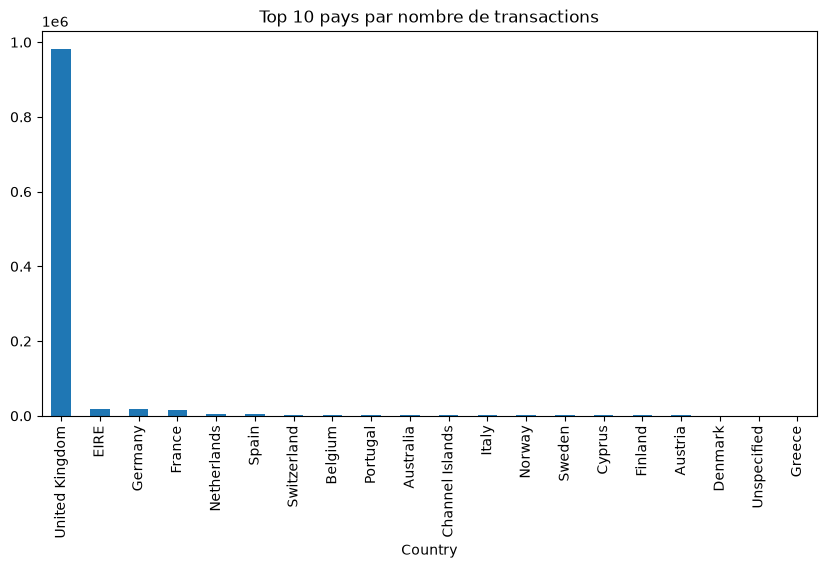

In [18]:
df["Country"].value_counts().head(20).plot(kind="bar", figsize=(10,5))
plt.title("Top 10 pays par nombre de transactions")
plt.show()

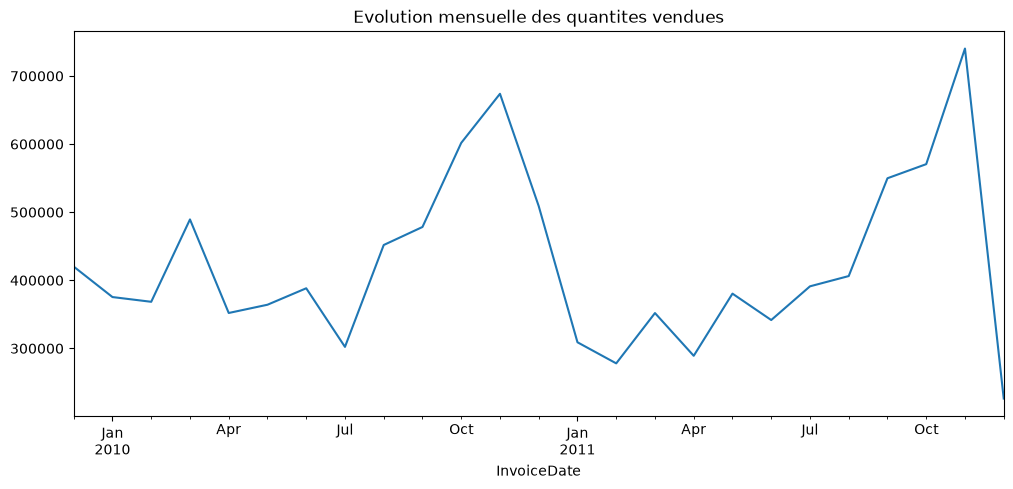

In [20]:
df.set_index("InvoiceDate").resample("ME")["Quantity"].sum().plot(figsize=(12,5))
plt.title("Evolution mensuelle des quantites vendues")
plt.show()

In [21]:
df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     108545
WHITE HANGING HEART T-LIGHT HOLDER     93050
ASSORTED COLOUR BIRD ORNAMENT          81306
JUMBO BAG RED RETROSPOT                78090
BROCADE RING PURSE                     70700
PACK OF 60 PINK PAISLEY CAKE CASES     56575
60 TEATIME FAIRY CAKE CASES            54366
SMALL POPCORN HOLDER                   49616
PACK OF 72 RETROSPOT CAKE CASES        49344
PACK OF 72 RETRO SPOT CAKE CASES       46106
Name: Quantity, dtype: int64

## 8. Synthèse des constats

- **Nombre total de lignes :** 1 067 371
- **Période couverte :** 01/12/2009 au 09/12/2011
- **Pourcentage de `Customer ID` manquants :** 22,77 %
- **Nombre de doublons :** 34 335
- **Nombre de lignes avec une quantité négative (`Quantity < 0`) :** 22 950 (principalement des retours ou annulations)
- **Nombre de lignes avec un prix unitaire inférieur ou égal à 0 (`Price <= 0`) :** 6 207
- **Codes produits non commerciaux identifiés :** `POST`, `DOT`, `M`, `BANK CHARGES` (ainsi que d'autres codes administratifs éventuels)
- **Principaux pays représentés :** United Kingdom (majoritaire), EIRE, Germany et France
- **Tendance observée :** Les ventes présentent une forte saisonnalité, avec un pic récurrent en novembre, suivi d'une baisse en début d'année. La diminution observée en décembre 2011 s'explique par le fait que les données de ce mois sont incomplètes.